# Unidad 2: Aprendizaje Automático
## NCA vs PCA — Reducción de Dimensionalidad Supervisada vs No Supervisada
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

<!-- <img src="https://raw.githubusercontent.com/CristianPacifico/ia-ls-fcad-uner/main/notebooks/ml/images/pexels-teona-swift-6913823.jpg" alt="Dimensionality Reduction" width="700"/>

*Foto de [Teona Swift](https://www.pexels.com/@teona-swift/) en [Pexels](https://www.pexels.com/)* -->

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/unsupervised/04_NCA_vs_PCA.ipynb)


## 🎯 Objetivos de Aprendizaje

Al finalizar este notebook vas a poder:

✅ Explicar la diferencia conceptual entre reducción **supervisada** y **no supervisada**  
✅ Implementar PCA y NCA con `scikit-learn`  
✅ Comparar ambas técnicas visualmente y en términos de accuracy de clasificación  
✅ Elegir la técnica adecuada según el contexto del problema  
✅ Usar `Pipeline` para integrar reducción de dimensionalidad en un flujo de ML

---

## 📖 Marco Teórico

### PCA — Principal Component Analysis (No Supervisado)

PCA proyecta los datos buscando las direcciones de **máxima varianza**, independientemente de las etiquetas de clase.

$$\max_{\mathbf{w}} \; \text{Var}(\mathbf{X}\mathbf{w}) \quad \text{sujeto a } \|\mathbf{w}\| = 1$$

**Cómo funciona:**
1. Centra los datos: $\tilde{X} = X - \bar{X}$
2. Calcula la matriz de covarianza: $C = \frac{1}{n-1}\tilde{X}^T\tilde{X}$
3. Descomposición espectral: $C\mathbf{v}_i = \lambda_i \mathbf{v}_i$
4. Los autovectores $\mathbf{v}_i$ son las componentes principales (ordenadas por $\lambda_i$ decreciente)

> 📌 PCA **no conoce las etiquetas**. Maximiza varianza global, que puede o no alinearse con la separación entre clases.

---

### NCA — Neighborhood Components Analysis (Supervisado)

NCA aprende una transformación lineal $A$ que **maximiza la accuracy esperada de un clasificador KNN** en el espacio transformado.

$$\max_{A} \; \sum_{i} \sum_{j \in C_i} p_{ij}$$

donde $p_{ij}$ es la probabilidad softmax de que el punto $j$ sea el vecino más cercano de $i$ en el espacio transformado $A\mathbf{x}$:

$$p_{ij} = \frac{\exp(-\|A\mathbf{x}_i - A\mathbf{x}_j\|^2)}{\sum_{k \neq i} \exp(-\|A\mathbf{x}_i - A\mathbf{x}_k\|^2)}, \quad p_{ii} = 0$$

y $C_i$ es el conjunto de puntos de la **misma clase** que $i$.

**Intuición:** NCA "junta" puntos de la misma clase y "separa" puntos de clases distintas, de forma análoga a cómo LDA, pero de manera no lineal en términos de la métrica aprendida.

> 📌 NCA **usa las etiquetas**. Por eso es supervisado y tiende a producir mejores proyecciones para clasificación.

---

### Comparación conceptual

| Característica | PCA | NCA |
|---|---|---|
| **Tipo** | No supervisado | Supervisado |
| **Objetivo** | Maximizar varianza | Maximizar accuracy KNN |
| **Usa etiquetas** | ❌ No | ✅ Sí |
| **Lineal** | ✅ Sí | ✅ Sí (transformación lineal) |
| **Costo computacional** | Bajo ($O(d^2 n)$) | Alto ($O(n^2)$ por iteración) |
| **Interpretabilidad** | Media (varianza explicada) | Baja |
| **Uso típico** | Exploración, compresión | Preprocesamiento para KNN |
| **Funciona sin etiquetas** | ✅ Sí | ❌ No |
| **En sklearn** | `decomposition.PCA` | `neighbors.NeighborhoodComponentsAnalysis` |


## ⚙️ Paso 1: Importar las Librerías


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NeighborhoodComponentsAnalysis, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

SEED = 42
np.random.seed(SEED)

print('✅ Librerías importadas correctamente')
print(f'   scikit-learn: PCA, NeighborhoodComponentsAnalysis, KNeighborsClassifier, Pipeline')


✅ Librerías importadas correctamente
   scikit-learn: PCA, NeighborhoodComponentsAnalysis, KNeighborsClassifier, Pipeline


## 📦 Paso 2: Cargar y Explorar los Datasets

Usaremos **tres datasets** progresivos:

| Dataset | Muestras | Features | Clases | Complejidad |
|---|---|---|---|---|
| **Iris** | 150 | 4 | 3 | Baja — warm-up |
| **Wine** | 178 | 13 | 3 | Media — interesante para reducción |
| **Digits** | 1797 | 64 | 10 | Alta — caso real de alta dimensión |

> 💡 En Iris la diferencia entre PCA y NCA puede ser sutil. En Wine y Digits la diferencia se vuelve más notoria.


In [2]:
# Cargar datasets
iris   = load_iris()
wine   = load_wine()
digits = load_digits()

datasets = {
    'Iris':   (iris.data,   iris.target,   iris.target_names),
    'Wine':   (wine.data,   wine.target,   wine.target_names),
    'Digits': (digits.data, digits.target, [str(i) for i in range(10)]),
}

print('📊 Resumen de los datasets:')
print(f"  {'Dataset':<10} {'Muestras':>10} {'Features':>10} {'Clases':>8}")
print('  ' + '-' * 42)
for nombre, (X, y, clases) in datasets.items():
    print(f"  {nombre:<10} {X.shape[0]:>10} {X.shape[1]:>10} {len(clases):>8}")

# Escalar todos
X_iris_sc   = StandardScaler().fit_transform(iris.data)
X_wine_sc   = StandardScaler().fit_transform(wine.data)
X_digits_sc = StandardScaler().fit_transform(digits.data)

print('\n✅ Datos escalados con StandardScaler listos.')
print('   ⚠️  Escalar es obligatorio tanto para PCA como para NCA.')


📊 Resumen de los datasets:
  Dataset      Muestras   Features   Clases
  ------------------------------------------
  Iris              150          4        3
  Wine              178         13        3
  Digits           1797         64       10

✅ Datos escalados con StandardScaler listos.
   ⚠️  Escalar es obligatorio tanto para PCA como para NCA.


## 🔵 Paso 3: PCA — Reducción No Supervisada

PCA transforma los datos buscando las **componentes de mayor varianza**. No sabe nada sobre las clases. Aplicamos PCA a los tres datasets y visualizamos la proyección 2D.


📊 Varianza explicada por PCA (2 componentes):
  Iris    : PC1=73.0%  PC2=22.9%  Total=95.8%
  Wine    : PC1=36.2%  PC2=19.2%  Total=55.4%
  Digits  : PC1=12.0%  PC2=9.6%  Total=21.6%


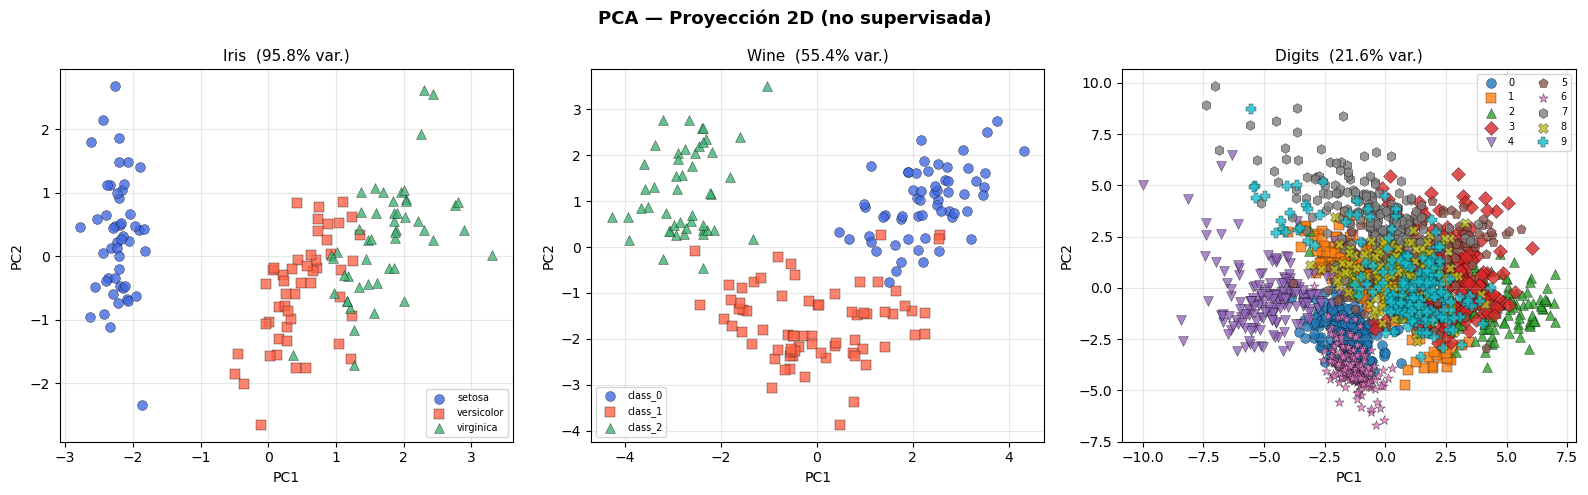

In [3]:
pca2 = PCA(n_components=2)

proyecciones_pca = {
    'Iris':   (pca2.fit_transform(X_iris_sc),   iris.target,   iris.target_names),
    'Wine':   (pca2.fit_transform(X_wine_sc),   wine.target,   wine.target_names),
    'Digits': (pca2.fit_transform(X_digits_sc), digits.target, [str(i) for i in range(10)]),
}

# Varianza explicada por dataset
print('📊 Varianza explicada por PCA (2 componentes):')
for nombre, X_sc in [('Iris', X_iris_sc), ('Wine', X_wine_sc), ('Digits', X_digits_sc)]:
    p = PCA(n_components=2).fit(X_sc)
    var = p.explained_variance_ratio_.sum() * 100
    print(f'  {nombre:<8}: PC1={p.explained_variance_ratio_[0]*100:.1f}%  '
          f'PC2={p.explained_variance_ratio_[1]*100:.1f}%  '
          f'Total={var:.1f}%')

# Paletas de colores
paletas = {
    'Iris':   ['royalblue', 'tomato', 'mediumseagreen'],
    'Wine':   ['royalblue', 'tomato', 'mediumseagreen'],
    'Digits': plt.cm.tab10.colors[:10],
}
formas = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', 'P']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PCA — Proyección 2D (no supervisada)', fontsize=13, fontweight='bold')

for ax, (nombre, (X_2d, y, clases)) in zip(axes, proyecciones_pca.items()):
    palet = paletas[nombre]
    for i, clase in enumerate(clases):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palet[i % len(palet)]], marker=formas[i % len(formas)],
                   label=clase, s=50, edgecolors='black', linewidths=0.3, alpha=0.8)
    p = PCA(n_components=2).fit(StandardScaler().fit_transform(
        {'Iris': iris.data, 'Wine': wine.data, 'Digits': digits.data}[nombre]))
    var = p.explained_variance_ratio_.sum() * 100
    ax.set_title(f'{nombre}  ({var:.1f}% var.)', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, ncol=2 if nombre == 'Digits' else 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🟠 Paso 4: NCA — Reducción Supervisada

NCA aprende una transformación lineal que maximiza la accuracy esperada de KNN. **Necesita las etiquetas** durante el `fit`. El resultado es un espacio donde los puntos de la misma clase están más agrupados.

> ⚠️ NCA puede ser lento en datasets grandes (complejidad $O(n^2)$). Para Digits (1797 muestras) puede tardar unos segundos.


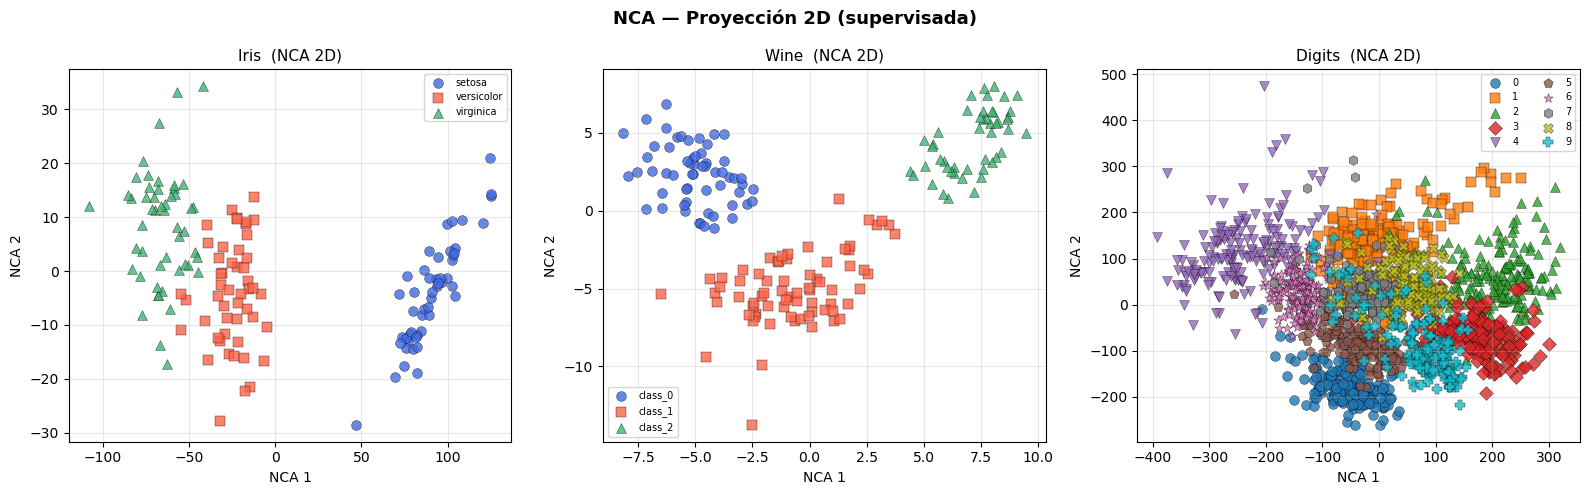

💡 Notar cómo NCA agrupa más compactamente las clases comparado con PCA.


In [4]:
nca2 = NeighborhoodComponentsAnalysis(n_components=2, random_state=SEED)

proyecciones_nca = {
    'Iris':   nca2.fit_transform(X_iris_sc,   iris.target),
    'Wine':   nca2.fit_transform(X_wine_sc,   wine.target),
    'Digits': nca2.fit_transform(X_digits_sc, digits.target),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NCA — Proyección 2D (supervisada)', fontsize=13, fontweight='bold')

configs = [
    ('Iris',   proyecciones_nca['Iris'],   iris.target,   iris.target_names,   paletas['Iris']),
    ('Wine',   proyecciones_nca['Wine'],   wine.target,   wine.target_names,   paletas['Wine']),
    ('Digits', proyecciones_nca['Digits'], digits.target, [str(i) for i in range(10)], paletas['Digits']),
]

for ax, (nombre, X_2d, y, clases, palet) in zip(axes, configs):
    for i, clase in enumerate(clases):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palet[i % len(palet)]], marker=formas[i % len(formas)],
                   label=clase, s=50, edgecolors='black', linewidths=0.3, alpha=0.8)
    ax.set_title(f'{nombre}  (NCA 2D)', fontsize=11)
    ax.set_xlabel('NCA 1')
    ax.set_ylabel('NCA 2')
    ax.legend(fontsize=7, ncol=2 if nombre == 'Digits' else 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('💡 Notar cómo NCA agrupa más compactamente las clases comparado con PCA.')


## 🔀 Paso 5: Comparación Visual lado a lado — PCA vs NCA

Comparamos las proyecciones 2D de PCA y NCA para cada dataset en una grilla.


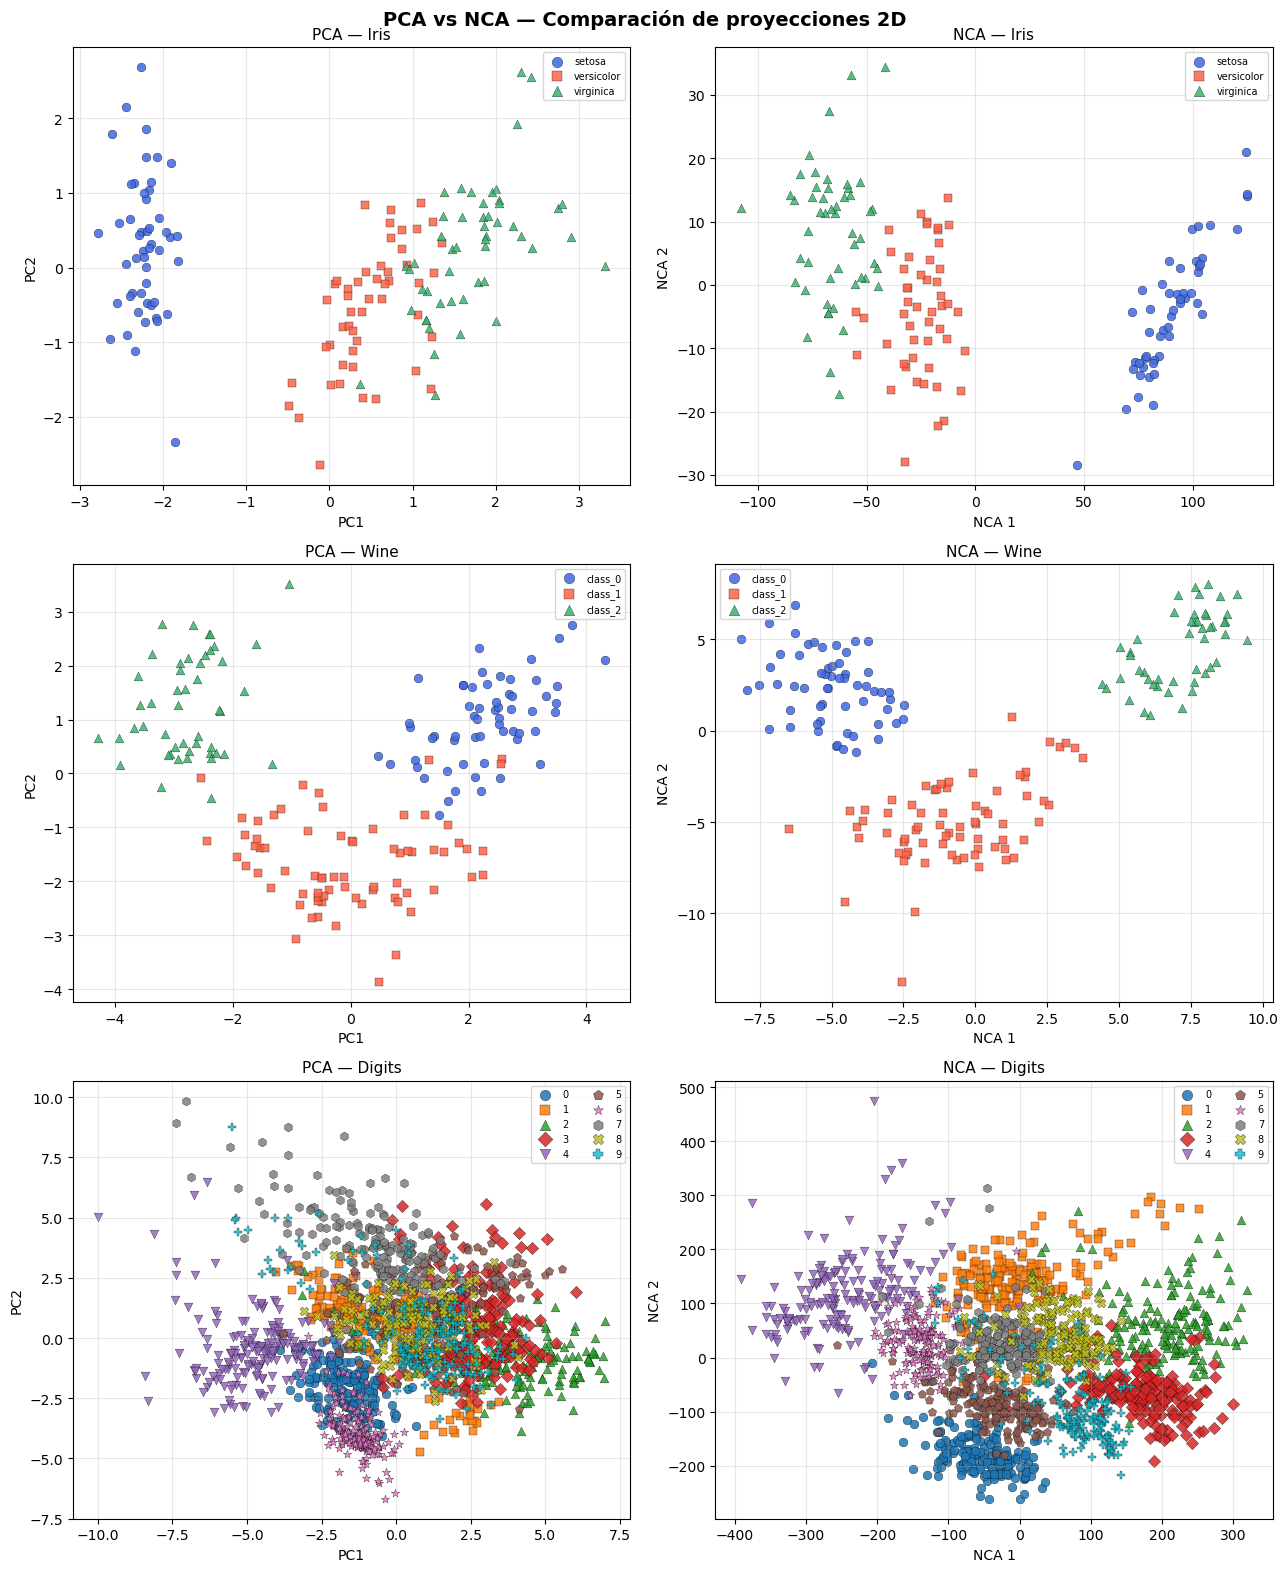

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(13, 16))
fig.suptitle('PCA vs NCA — Comparación de proyecciones 2D', fontsize=14, fontweight='bold')

comp_data = [
    ('Iris',   X_iris_sc,   iris.target,   iris.target_names,   paletas['Iris']),
    ('Wine',   X_wine_sc,   wine.target,   wine.target_names,   paletas['Wine']),
    ('Digits', X_digits_sc, digits.target, [str(i) for i in range(10)], paletas['Digits']),
]

for fila, (nombre, X_sc, y, clases, palet) in enumerate(comp_data):
    X_pca_2d = PCA(n_components=2).fit_transform(X_sc)
    X_nca_2d = NeighborhoodComponentsAnalysis(n_components=2,
                                               random_state=SEED).fit_transform(X_sc, y)

    for col, (X_2d, titulo, eje1, eje2) in enumerate([
        (X_pca_2d, f'PCA — {nombre}', 'PC1', 'PC2'),
        (X_nca_2d, f'NCA — {nombre}', 'NCA 1', 'NCA 2'),
    ]):
        ax = axes[fila, col]
        for i, clase in enumerate(clases):
            mask = y == i
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[palet[i % len(palet)]], marker=formas[i % len(formas)],
                       label=clase, s=40, edgecolors='black', linewidths=0.25, alpha=0.85)
        ax.set_title(titulo, fontsize=11)
        ax.set_xlabel(eje1)
        ax.set_ylabel(eje2)
        ax.legend(fontsize=7, ncol=2 if nombre == 'Digits' else 1,
                  loc='best', markerscale=1.2)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🤖 Paso 6: Impacto en la Clasificación — KNN con Pipeline

La pregunta clave es: **¿cuál técnica ayuda más a un clasificador KNN?**

Comparamos 4 configuraciones usando `Pipeline` y `cross_val_score` (CV estratificado, k=5):

1. **KNN puro** — sin reducción, solo escalar
2. **Scaler → PCA(2D) → KNN**
3. **Scaler → NCA(2D) → KNN**
4. **Scaler → NCA(mejor k) → KNN** — NCA con tantas componentes como clases-1

> 🔑 El `Pipeline` garantiza que el escalado y la reducción se ajusten **solo sobre los datos de entrenamiento** en cada fold — sin data leakage.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
resultados_cv = {}

experimentos = {
    'Iris':   (iris.data,   iris.target,   3),   # 3 clases → NCA máx 2D
    'Wine':   (wine.data,   wine.target,   3),   # 3 clases → NCA máx 2D
    'Digits': (digits.data, digits.target, 10),  # 10 clases → NCA máx 9D
}

for nombre, (X_raw, y, n_clases) in experimentos.items():
    configs = {
        'KNN (sin reducción)':      Pipeline([('sc', StandardScaler()),
                                              ('knn', KNeighborsClassifier(5))]),
        'PCA 2D → KNN':             Pipeline([('sc',  StandardScaler()),
                                              ('pca', PCA(n_components=2)),
                                              ('knn', KNeighborsClassifier(5))]),
        'NCA 2D → KNN':             Pipeline([('sc',  StandardScaler()),
                                              ('nca', NeighborhoodComponentsAnalysis(
                                                          n_components=2, random_state=SEED)),
                                              ('knn', KNeighborsClassifier(5))]),
        f'NCA {n_clases-1}D → KNN': Pipeline([('sc',  StandardScaler()),
                                              ('nca', NeighborhoodComponentsAnalysis(
                                                          n_components=n_clases-1,
                                                          random_state=SEED)),
                                              ('knn', KNeighborsClassifier(5))]),
    }
    resultados_cv[nombre] = {}
    for cfg_nombre, pipe in configs.items():
        scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring='accuracy')
        resultados_cv[nombre][cfg_nombre] = (scores.mean(), scores.std())

# Mostrar tabla
print('📊 Accuracy KNN (CV=5 estratificado):\n')
for nombre in ['Iris', 'Wine', 'Digits']:
    print(f'  ── {nombre} ──')
    print(f"    {'Configuración':<30} {'Media':>8}  {'±Std':>6}")
    print(f"    {'-'*48}")
    best_score = max(v[0] for v in resultados_cv[nombre].values())
    for cfg, (media, std) in resultados_cv[nombre].items():
        marker = ' ◄ mejor' if abs(media - best_score) < 1e-9 else ''
        print(f"    {cfg:<30} {media*100:>7.2f}%  ±{std*100:.2f}%{marker}")
    print()


📊 Accuracy KNN (CV=5 estratificado):

  ── Iris ──
    Configuración                     Media    ±Std
    ------------------------------------------------
    KNN (sin reducción)              97.33%  ±2.49% ◄ mejor
    PCA 2D → KNN                     92.00%  ±5.42%
    NCA 2D → KNN                     96.67%  ±4.22%

  ── Wine ──
    Configuración                     Media    ±Std
    ------------------------------------------------
    KNN (sin reducción)              97.17%  ±1.81%
    PCA 2D → KNN                     96.65%  ±2.07%
    NCA 2D → KNN                     98.32%  ±1.37% ◄ mejor

  ── Digits ──
    Configuración                     Media    ±Std
    ------------------------------------------------
    KNN (sin reducción)              97.89%  ±0.63% ◄ mejor
    PCA 2D → KNN                     52.92%  ±1.20%
    NCA 2D → KNN                     77.35%  ±1.54%
    NCA 9D → KNN                     97.33%  ±0.67%



## 📈 Paso 7: Accuracy vs Número de Componentes

¿Cómo evoluciona la accuracy de KNN al aumentar el número de componentes en PCA y NCA? Usamos **Wine** (13 features → máx 12 componentes) y **Digits** (64 features → máx 9 para NCA, hasta 30 para PCA).


⏳ Calculando sweep para Wine…
⏳ Calculando sweep para Digits…


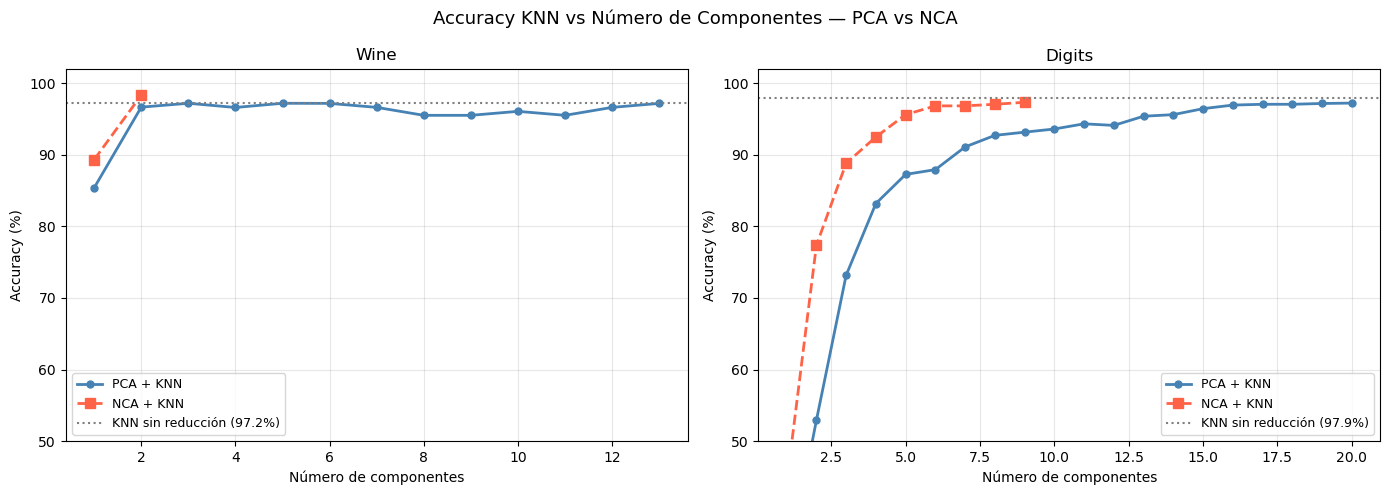


💡 Observaciones:
   · NCA alcanza su máximo con muchas menos componentes (limitado por n_clases - 1).
   · PCA necesita más componentes para alcanzar su pico.
   · NCA suele superar a PCA para KNN, especialmente con pocas componentes.


In [7]:
def sweep_componentes(X_raw, y, n_clases, nombre_ds):
    """Barre n_components para PCA y NCA y devuelve accuracy media (CV=5)."""
    max_pca = min(X_raw.shape[1], 20)
    max_nca = n_clases - 1   # NCA no puede superar n_clases - 1

    comp_pca = range(1, max_pca + 1)
    comp_nca = range(1, max_nca + 1)

    acc_pca, acc_nca = [], []
    for k in comp_pca:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('pca', PCA(n_components=k)),
                         ('knn', KNeighborsClassifier(5))])
        acc_pca.append(cross_val_score(pipe, X_raw, y, cv=cv, scoring='accuracy').mean())

    for k in comp_nca:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('nca', NeighborhoodComponentsAnalysis(n_components=k,
                                                                  random_state=SEED)),
                         ('knn', KNeighborsClassifier(5))])
        acc_nca.append(cross_val_score(pipe, X_raw, y, cv=cv, scoring='accuracy').mean())

    return list(comp_pca), acc_pca, list(comp_nca), acc_nca

# Sweep para Wine y Digits
print('⏳ Calculando sweep para Wine…')
cp_w, ap_w, cn_w, an_w = sweep_componentes(wine.data,   wine.target,   3,  'Wine')
print('⏳ Calculando sweep para Digits…')
cp_d, ap_d, cn_d, an_d = sweep_componentes(digits.data, digits.target, 10, 'Digits')

# KNN sin reducción (baseline)
base_wine   = cross_val_score(
    Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier(5))]),
    wine.data, wine.target, cv=cv, scoring='accuracy').mean()
base_digits = cross_val_score(
    Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier(5))]),
    digits.data, digits.target, cv=cv, scoring='accuracy').mean()

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Accuracy KNN vs Número de Componentes — PCA vs NCA', fontsize=13)

for ax, (nombre, cp, ap, cn, an, base) in zip(axes, [
    ('Wine',   cp_w, ap_w, cn_w, an_w, base_wine),
    ('Digits', cp_d, ap_d, cn_d, an_d, base_digits),
]):
    ax.plot(cp, [v * 100 for v in ap], 'o-', color='steelblue', linewidth=2,
            markersize=5, label='PCA + KNN')
    ax.plot(cn, [v * 100 for v in an], 's--', color='tomato', linewidth=2,
            markersize=7, label='NCA + KNN')
    ax.axhline(base * 100, color='gray', linestyle=':', linewidth=1.5,
               label=f'KNN sin reducción ({base*100:.1f}%)')
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel('Número de componentes')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(50, 102)

plt.tight_layout()
plt.show()

print()
print('💡 Observaciones:')
print('   · NCA alcanza su máximo con muchas menos componentes (limitado por n_clases - 1).')
print('   · PCA necesita más componentes para alcanzar su pico.')
print('   · NCA suele superar a PCA para KNN, especialmente con pocas componentes.')


## 🎓 Resumen y Conclusiones

### Mini resumen tipo clase

| Pregunta | PCA | NCA |
|---|---|---|
| ¿Usa las etiquetas? | ❌ No | ✅ Sí |
| ¿Para qué? | Reducción general, visualización, compresión | Preprocesamiento para KNN |
| ¿Cuántas componentes máximas? | min(n_samples, n_features) | n_clases − 1 |
| ¿Cuándo supera al otro? | Cuando no hay etiquetas, datasets grandes | Cuando el objetivo es clasificar con KNN |
| ¿Costo computacional? | Bajo | Alto (escala con $n^2$) |

### ¿Cuándo usar cada uno?

**Usar PCA cuando:**
- No tenés etiquetas (aprendizaje no supervisado)
- Querés explorar / visualizar datos sin sesgo de clase
- El dataset es muy grande y NCA sería demasiado lento
- Buscás compresión o preprocesamiento general

**Usar NCA cuando:**
- El clasificador final **es** KNN (o similar basado en distancias)
- Tenés etiquetas disponibles y querés maximizar accuracy
- El dataset es de tamaño moderado

### ⚠️ Errores comunes

| Error | Problema | Solución |
|---|---|---|
| Usar NCA sin escalar | Los pesos de la transformación se distorsionan | `StandardScaler` obligatorio antes |
| Usar NCA con n_comp > n_clases−1 | Error de sklearn | NCA tiene un límite superior: `n_clases - 1` |
| Aplicar fit en test | Data leakage | Siempre usar `Pipeline` |
| Esperar interpretabilidad de NCA | NCA no tiene "varianza explicada" | Es una caja negra para clasificación |

### 🚀 ¿Qué sigue?

- 📐 **LDA (Linear Discriminant Analysis)** — reducción supervisada con proyección explícita hacia los centroides de clase
- 🌐 **UMAP** — no lineal, más moderno que t-SNE, funciona bien con etiquetas (modo supervisado)
- 🧠 **Metric Learning** — familia de técnicas que incluye NCA: LMNN, MLKR

> 📚 **Referencias:**
> - [scikit-learn — NeighborhoodComponentsAnalysis](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NeighborhoodComponentsAnalysis.html)
> - [scikit-learn — Neighborhood Components Analysis](https://scikit-learn.org/stable/modules/neighbors.html#neighborhood-components-analysis)
> - Goldberger, J., Roweis, S., Hinton, G., & Salakhutdinov, R. (2004). *Neighbourhood Components Analysis*. NIPS 2004.
> - [scikit-learn — PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)


---
<br>

**Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER**

Este notebook está licenciado bajo [Creative Commons BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
Podés compartirlo y adaptarlo con atribución y bajo la misma licencia.

*Cristian Pacifico — FCAD/UNER*
